# Trabajo Práctico: Desarrollo de un Modelo Predictivo Vinculado al TFM
---
### Máster en Big Data & Business Intelligence 2025/2026  
### Asignatura 7: Modelado Predictivo con Machine Learning 
**Universidad:** Next Educación  
**Curso académico:** Febrero 2026  
**Alumno:** Sergio Solórzano Alfaro  
**Fecha de entrega:** 4 de Octubre, 2026 

---

Este cuaderno está dividido en dos secciones de contenido:
1. El conjunto de consultas y resultados que se utilizaron para **análisis preeliminar de datos** presentes en la base de datos construida a partir de información histórica de SICOP (proveedores, instituciones, carteles, ofertas y adjudicaciones).
2. Un conjunto de consultas para la **construcción del data set final con el que se entrenó un modelo predictivo de clasificación (Random Forest)** para calcular la probabilidad de adjudicación que tendrán ofertas presentadas pero que aún no han sido adjudicadas. En esta misma sección se evaluá y selecciona el mejor conjunto de hiperparámetros para el modelo y además se grafican los resultados de evaluación del modelo.

---

## 1. Análisis preeliminar de datos

Cómo primer paso, será necesario descargar, en su computadora, la base de datos publicada en el siguiente release del repositorio: [Base de datos SICOP](https://github.com/ssolorzanocr/Modelo_predictivo_SICOP/releases/download/datos_actuales_sicop/sicop.duckdb)  
Para efectos de este cuaderno, la base de datos utilizada posee <u>registros que comprenden un periodo desde Enero 2025 hasta Septiembre del 2026</u> (21 meses).

Luego, debemos instalar las librerías para ejecutar los fragmentos de código python en este cuaderno de Jupiter:  
`python -m pip install --upgrade pip`
`pip install duckdb pandas matplotlib scikit-learn`

Ahora, crearemos una conexión a la base de datos local en el ordenador e imprimimos las tablas disponibles del modelo de datos.

In [28]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
import os

load_dotenv()

RUTA_BASE_DE_DATOS = os.getenv("RUTA_DATOS")
print(f"Ruta de la base de datos: {RUTA_BASE_DE_DATOS}")

con = duckdb.connect(
    RUTA_BASE_DE_DATOS,
    read_only=True
)

Ruta de la base de datos: localdata\sicop.duckdb


Exploramos el contenido de la base de datos a nivel general.  
Observamos que hay dos schemas en la base datos. Para efectos de este cuaderno solo nos interesa el schema llamado 'final'.  

In [29]:
con.sql("SHOW ALL TABLES").df()

,database,schema,name,column_names,column_types,temporary
0,sicop,final,dim_instituciones,"[cedula, nombre_institucion, zona_geo_inst, fe...","[VARCHAR, VARCHAR, VARCHAR, DATE, BIGINT]",False
1,sicop,final,dim_productos,"[cod_producto, descripcion_producto, segmento,...","[BIGINT, VARCHAR, INTEGER, VARCHAR]",False
2,sicop,final,dim_proveedores,"[cedula_proveedor, nombre_proveedor, tipo_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
3,sicop,final,fact_lineas_adjudicadas,"[nro_sicop, nro_linea, nro_oferta, cedula_inst...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
4,sicop,final,fact_lineas_carteles,"[nro_sicop, numero_linea, numero_partida, cedu...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, DATE, VAR...",False
5,sicop,final,fact_lineas_ofertas,"[nro_sicop, nro_oferta, nro_linea, cedula_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, DATE, VAR...",False
6,sicop,staging,dim_instituciones,"[cedula, nombre_institucion, zona_geo_inst, fe...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR]",False
7,sicop,staging,dim_proveedores,"[cedula_proveedor, nombre_proveedor, tipo_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
8,sicop,staging,fact_adjudicaciones,"[nro_sicop, cedula, numero_procedimiento, desc...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
9,sicop,staging,fact_carteles,"[nro_sicop, cedula_institucion, fecha_publicac...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False


Mostramos ahora las columnas de datos en el schema final:

In [30]:
pd.set_option("display.max_rows", None)

con.sql("""
    SELECT
        database_name,
        schema_name,
        table_name,
        column_name,
        data_type
    FROM duckdb_columns()
    WHERE NOT internal and schema_name = 'final'
    ORDER BY table_name
""").df()

,database_name,schema_name,table_name,column_name,data_type
0,sicop,final,dim_instituciones,cedula,VARCHAR
1,sicop,final,dim_instituciones,nombre_institucion,VARCHAR
2,sicop,final,dim_instituciones,zona_geo_inst,VARCHAR
3,sicop,final,dim_instituciones,fecha_ingreso,DATE
4,sicop,final,dim_instituciones,proveedores_adjudicados_distintos,BIGINT
5,sicop,final,dim_productos,cod_producto,BIGINT
6,sicop,final,dim_productos,descripcion_producto,VARCHAR
7,sicop,final,dim_productos,segmento,INTEGER
8,sicop,final,dim_productos,nombre_segmento,VARCHAR
9,sicop,final,dim_proveedores,porcentaje_exito,DOUBLE


Exploremos la cantidad de registros y cantidad de valores nulos para cada tabla en el periodo estudiado.

In [31]:
for table in con.sql("""
    SELECT
        database_name,
        schema_name,
        table_name,
        column_name,
        data_type
    FROM duckdb_columns()
    WHERE NOT internal and schema_name = 'final'
    ORDER BY table_name
    """).df().table_name.unique():
    print("__________________________________")
    print(f"Registros en final.{table}: {con.sql(f'SELECT COUNT(*) AS total_registros FROM final.{table}').df().values[0]}")
    print(f"Columnas en final.{table}: {con.sql(f'SELECT COUNT(*) AS total_columnas FROM duckdb_columns() WHERE schema_name = \'final\' AND table_name = \'{table}\'').df().values[0]}")
    print(f"cantidad de valores nulos por columna en final.{table}:")
    for column in con.sql(f"SELECT column_name FROM duckdb_columns() WHERE schema_name = 'final' AND table_name = '{table}'").df().column_name:
        nulos = con.sql(f"SELECT COUNT(*) AS nulos FROM final.{table} WHERE {column} IS NULL").df().values[0]
        print(f"  - {column}: {nulos}")


__________________________________
Registros en final.dim_instituciones: [691]
Columnas en final.dim_instituciones: [5]
cantidad de valores nulos por columna en final.dim_instituciones:
  - cedula: [0]
  - nombre_institucion: [0]
  - zona_geo_inst: [0]
  - fecha_ingreso: [8]
  - proveedores_adjudicados_distintos: [0]
__________________________________
Registros en final.dim_productos: [105044]
Columnas en final.dim_productos: [4]
cantidad de valores nulos por columna en final.dim_productos:
  - cod_producto: [0]
  - descripcion_producto: [3459]
  - segmento: [0]
  - nombre_segmento: [0]
__________________________________
Registros en final.dim_proveedores: [58473]
Columnas en final.dim_proveedores: [8]
cantidad de valores nulos por columna en final.dim_proveedores:
  - cedula_proveedor: [0]
  - nombre_proveedor: [0]
  - tipo_proveedor: [0]
  - tamano_proveedor: [0]
  - zona_geo_prov: [0]
  - fecha_registro: [3]
  - porcentaje_exito: [53881]
  - productos_distintos_ofertados: [0]
______

---
Estudiemos el comportamiento de las **instituciones**.  

In [58]:
print(f"Cantidad de instituciones activas: {con.sql('SELECT COUNT(DISTINCT cedula_institucion) AS cantidad_instituciones_activas FROM final.fact_lineas_carteles').df().values[0][0]}")

df_promedio_mensual = con.execute("""
    WITH carteles_por_mes AS (
        SELECT
            c.cedula_institucion,
            date_trunc('month', c.fecha_publicacion) AS mes,
            COUNT(DISTINCT c.nro_sicop) AS carteles_mes
        FROM final.fact_lineas_carteles c
        WHERE c.fecha_publicacion IS NOT NULL
        GROUP BY c.cedula_institucion, date_trunc('month', c.fecha_publicacion)
    )
    SELECT
        cpm.cedula_institucion,
        i.nombre_institucion,
        ROUND(AVG(cpm.carteles_mes), 2) AS promedio_carteles_mes,
        COUNT(*) AS meses_con_actividad,
        SUM(cpm.carteles_mes) AS total_carteles
    FROM carteles_por_mes cpm
    LEFT JOIN final.dim_instituciones i ON i.cedula = cpm.cedula_institucion
    GROUP BY cpm.cedula_institucion, i.nombre_institucion
    ORDER BY promedio_carteles_mes DESC
""").df()

df_proveedores_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(DISTINCT a.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY proveedores_distintos DESC
""").df()

df_productos_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(DISTINCT a.cod_producto) AS productos_distintos
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY productos_distintos DESC
""").df()

resumen_periodo = con.execute("""
    SELECT
        COUNT(*) AS adjudicaciones_totales,
        MIN(fecha_adjudicacion) AS desde,
        MAX(fecha_adjudicacion) AS hasta
    FROM final.fact_lineas_adjudicadas
""").df()

print(resumen_periodo)

df_adjudicaciones_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(*) AS adjudicaciones_totales
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY adjudicaciones_totales DESC
""").df()

resumen_instituciones = (
    df_promedio_mensual
    .merge(df_proveedores_inst[["cedula_institucion", "proveedores_distintos"]], on="cedula_institucion", how="outer")
    .merge(df_productos_inst[["cedula_institucion", "productos_distintos"]], on="cedula_institucion", how="outer")
    .merge(df_adjudicaciones_inst[["cedula_institucion", "adjudicaciones_totales"]], on="cedula_institucion", how="outer")
    .sort_values("total_carteles", ascending=False)
)

resumen_instituciones.head(30)

Cantidad de instituciones activas: 379
   adjudicaciones_totales      desde      hasta
0                   61606 2025-01-02 2026-09-10


,cedula_institucion,nombre_institucion,promedio_carteles_mes,meses_con_actividad,total_carteles,proveedores_distintos,productos_distintos,adjudicaciones_totales
372,4000042147,CAJA COSTARRICENSE DE SEGURO SOCIAL,316.91,22.0,6972.0,645.0,9653.0,14058.0
237,3014042058,MUNICIPALIDAD DEL CANTÓN CENTRAL DE SAN JOSÉ,77.27,22.0,1700.0,242.0,697.0,1217.0
374,4000042149,UNIVERSIDAD DE COSTA RICA,76.23,22.0,1677.0,354.0,2293.0,2430.0
21,2300042155,CORTE SUPREMA DE JUSTICIA-PODER JUDICIAL,73.68,22.0,1621.0,174.0,670.0,999.0
364,4000042139,INSTITUTO COSTARRICENSE DE ELECTRICIDAD,72.95,22.0,1605.0,263.0,2949.0,3870.0
379,4000045127,INSTITUTO NACIONAL DE APRENDIZAJE,60.55,22.0,1332.0,205.0,1685.0,1876.0
360,4000001902,INSTITUTO NACIONAL DE SEGUROS,50.95,22.0,1121.0,224.0,1286.0,2183.0
361,4000004017,BANCO CENTRAL DE COSTA RICA,40.14,21.0,843.0,79.0,74.0,228.0
207,3007556085,UNIVERSIDAD TÉCNICA NACIONAL,33.41,22.0,735.0,118.0,271.0,289.0
162,3007111111,COMISIÓN NACIONAL DE PREVENCIÓN DE RIESGOS Y A...,33.23,22.0,731.0,45.0,67.0,269.0


---
Ahora, creemos analíticas enfocadas en el comportamiento de los **productos** registrados.

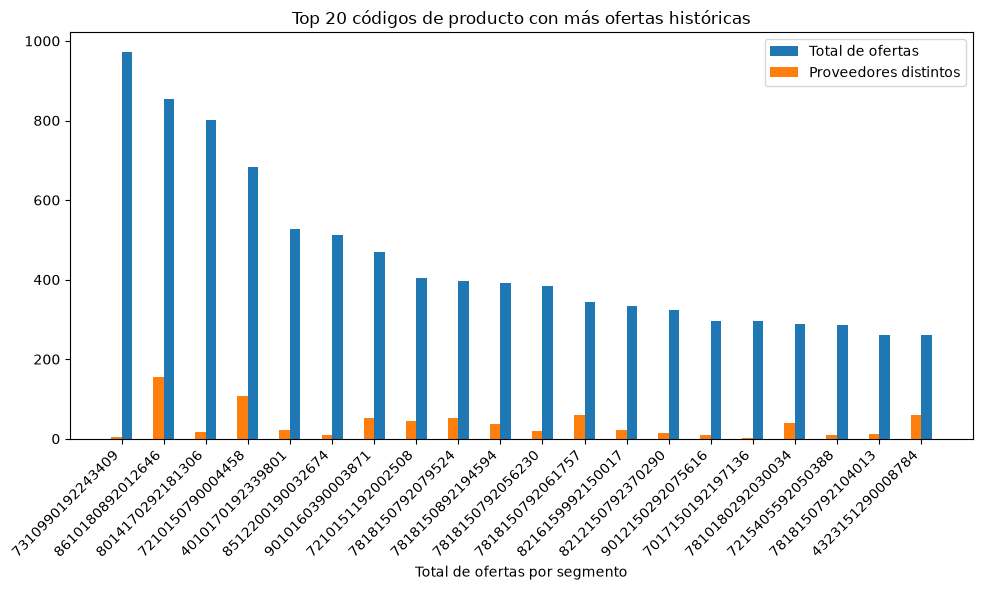

In [44]:
# top productos por total de ofertas
df_productos = con.execute("""
    SELECT
        o.cod_producto,
        p.descripcion_producto,
        p.segmento,
        p.nombre_segmento,
        COUNT(*) AS total_ofertas,
        COUNT(DISTINCT o.nro_sicop || '-' || o.nro_linea) AS lineas_distintas,
        COUNT(DISTINCT o.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_ofertas o
    LEFT JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(o.cod_producto AS BIGINT)
    GROUP BY o.cod_producto, p.descripcion_producto, p.segmento, p.nombre_segmento
    ORDER BY total_ofertas DESC
""").df()

top20 = df_productos.head(20).copy()
top20["etiqueta"] = top20["descripcion_producto"].fillna(top20["cod_producto"]).str.slice(0, 40)

x = np.arange(len(top20["segmento"]))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x + width/2, top20["total_ofertas"], width, label="Total de ofertas")
ax.bar(x - width/2, top20["proveedores_distintos"], width, label="Proveedores distintos")

ax.set_xlabel("Total de ofertas por segmento")
ax.set_title("Top 20 códigos de producto con más ofertas históricas")

ax.set_xticks(x)
ax.set_xticklabels(top20["cod_producto"], rotation=45, ha="right")


ax.legend()

plt.tight_layout()
plt.show()


Total de segmentos con ofertas distintos: 57


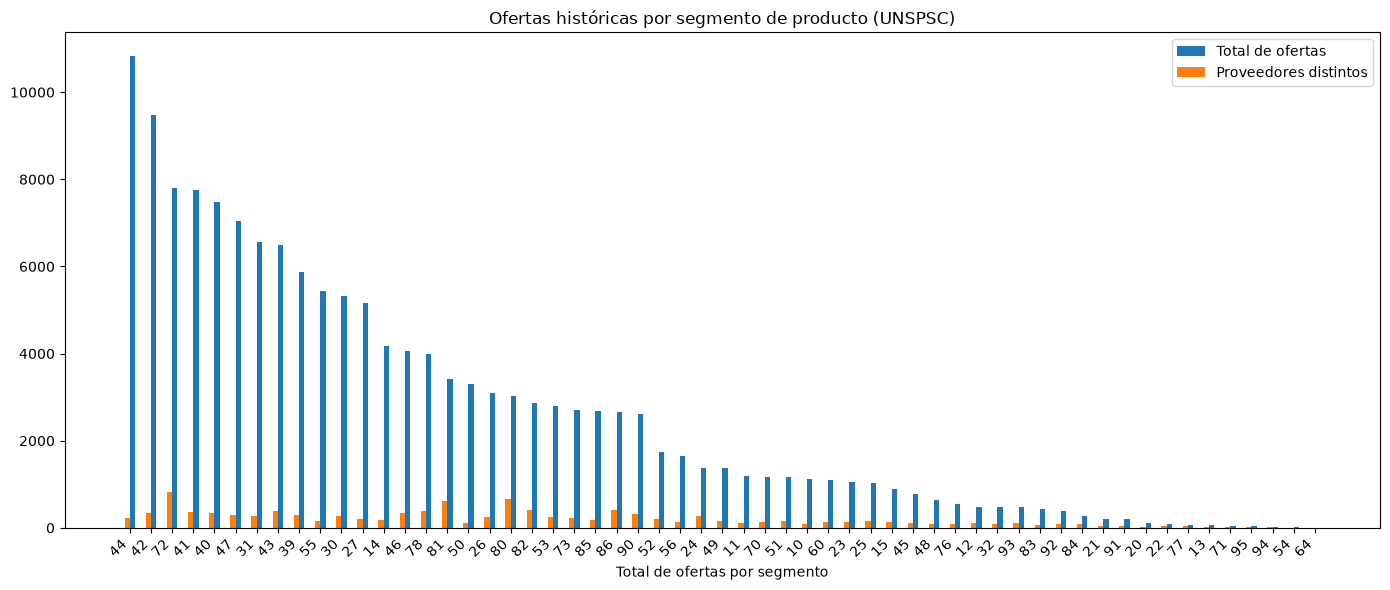

In [56]:
# top segmentos por total de ofertas
df_segmentos = con.execute("""
    SELECT
        p.segmento,
        p.nombre_segmento,
        COUNT(*) AS total_ofertas,
        COUNT(DISTINCT o.nro_sicop || '-' || o.nro_linea) AS lineas_distintas,
        COUNT(DISTINCT o.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_ofertas o
    LEFT JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(o.cod_producto AS BIGINT)
    GROUP BY p.segmento, p.nombre_segmento
    ORDER BY total_ofertas DESC
""").df()

print(f"Total de segmentos con ofertas distintos: {len(df_segmentos)}")

x = np.arange(len(df_segmentos["segmento"]))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x + width/2, df_segmentos["total_ofertas"], width, label="Total de ofertas")
ax.bar(x - width/2, df_segmentos["proveedores_distintos"], width, label="Proveedores distintos")

ax.set_xlabel("Total de ofertas por segmento")
ax.set_title("Ofertas históricas por segmento de producto (UNSPSC)")

ax.set_xticks(x)
ax.set_xticklabels(df_segmentos["segmento"], rotation=45, ha="right")

ax.legend()

plt.tight_layout()
plt.show()



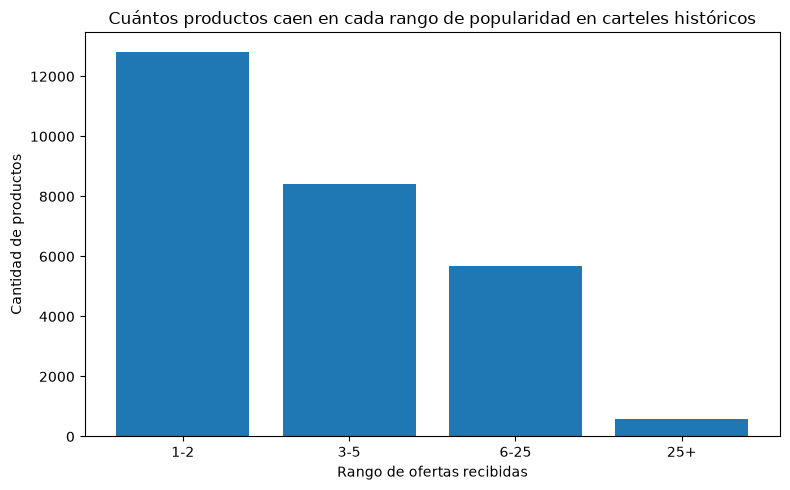

In [48]:
df_buckets = con.execute("""
    WITH ofertas_por_producto AS (
        SELECT cod_producto, COUNT(*) AS total_ofertas
        FROM final.fact_lineas_ofertas
        GROUP BY cod_producto
    )
    SELECT
        CASE
            WHEN total_ofertas BETWEEN 1 AND 2   THEN '1-2'
            WHEN total_ofertas BETWEEN 3 AND 5   THEN '3-5'
            WHEN total_ofertas BETWEEN 6 AND 25  THEN '6-25'
            ELSE '25+'
        END AS rango_ofertas,
        COUNT(*) AS cantidad_productos
    FROM ofertas_por_producto
    GROUP BY 1
""").df()

orden = ["1-2", "3-5", "6-25", "25+"]
df_buckets["rango_ofertas"] = pd.Categorical(df_buckets["rango_ofertas"], categories=orden, ordered=True)
df_buckets = df_buckets.sort_values("rango_ofertas")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_buckets["rango_ofertas"].astype(str), df_buckets["cantidad_productos"])
ax.set_xlabel("Rango de ofertas recibidas")
ax.set_ylabel("Cantidad de productos")
ax.set_title("Cuántos productos caen en cada rango de popularidad en carteles históricos")
plt.tight_layout()
plt.show()

In [49]:
con.sql("""
    SELECT *
    FROM final.dim_proveedores
    LIMIT 5
""").df()

,cedula_proveedor,nombre_proveedor,tipo_proveedor,tamano_proveedor,zona_geo_prov,fecha_registro,porcentaje_exito,productos_distintos_ofertados
0,108190851,ANA MARCELA SOLANO SOLERA,Nacional Físico,Pequeña,"Guadalupe, Goicoechea, San José",2025-02-20,1.000000,1
1,3101773954,VIAJES TRISTAN SOCIEDAD ANONIMA,Nacional Jurídico,Grande,"Catedral, San José, San José",2025-09-08,0.391304,6
2,3101090610,E S CONSULTORIA Y CONSTRUCCION SOCIEDAD ANONIMA,Nacional Jurídico,Pequeña,"Alajuela, Alajuela, Alajuela",2010-05-11,0.093023,24
3,3102032966,TITAN REPRESENTACIONES Y SUMINISTROS LIMITADA,Nacional Jurídico,Mediana,"Guadalupe, Goicoechea, San José",2010-05-20,1.000000,1
4,3101303276,TODO EN FRENOS Y CLUTCH DOS MIL UNO SOCIEDAD A...,Nacional Jurídico,Grande,"Purral, Goicoechea, San José",2012-02-29,0.333333,9


In [50]:
# Cantidad de proveedores por tamaño
con.execute("""
    SELECT
        tamano_proveedor,
        COUNT(*) AS cantidad_proveedores
    FROM final.dim_proveedores
    GROUP BY tamano_proveedor
    ORDER BY cantidad_proveedores DESC
""").df()

,tamano_proveedor,cantidad_proveedores
0,Pequeña,19925
1,Microemprendedor,19790
2,Grande,10578
3,Mediana,7173
4,No clasificado,1007


---
Ahora, exploremos los datos presentes en **fact lineas carteles**.

In [51]:
# Cantidad de carteles por tipo de procedimiento
con.execute("""
    SELECT
        tipo_procedimiento,
        COUNT(*) AS cantidad_lineas_carteles
    FROM final.fact_lineas_carteles
    GROUP BY tipo_procedimiento
    ORDER BY cantidad_lineas_carteles DESC
""").df()

,tipo_procedimiento,cantidad_lineas_carteles
0,LICITACIÓN REDUCIDA,194278
1,LICITACIÓN MENOR,55895
2,LICITACIÓN MAYOR,47490
3,PROCEDIMIENTOS ESPECIALES,31366
4,PROCEDIMIENTO POR EXCEPCIÓN,27794
5,REMATE,1165
6,SUBASTA INVERSA ELECTRÓNICA,296
7,LICITACIÓN PÚBLICA NACIONAL,1


In [52]:
#3. ¿Qué porcentaje de líneas de cartel no tiene NINGUNA oferta?
con.sql("""
SELECT
    COUNT(*) AS total_lineas_cartel,
    COUNT(*) FILTER (WHERE o.n IS NULL) AS sin_ofertas,
    ROUND(100.0 * COUNT(*) FILTER (WHERE o.n IS NULL) / COUNT(*), 1) AS pct_sin_ofertas
FROM final.fact_lineas_carteles c
LEFT JOIN (
    SELECT nro_sicop, nro_linea, COUNT(*) AS n
    FROM final.fact_lineas_ofertas
    GROUP BY nro_sicop, nro_linea
) o ON o.nro_sicop = c.nro_sicop AND o.nro_linea = c.numero_linea;
""").df()

,total_lineas_cartel,sin_ofertas,pct_sin_ofertas
0,358285,310812,86.7


In [53]:
#4. En promedio, ¿cuántas líneas cubre una sola oferta?
con.sql("""
SELECT 
    MAX(lineas_por_oferta) AS maximo,
    MIN(lineas_por_oferta) AS minimo,
    AVG(lineas_por_oferta) AS promedio,
    COUNT(*) AS total_ofertas
FROM (SELECT nro_oferta, COUNT(*) AS lineas_por_oferta
      FROM final.fact_lineas_ofertas GROUP BY nro_oferta)
""").df()

,maximo,minimo,promedio,total_ofertas
0,99,1,1.788616,82007


---
Estadísticas sobre precios en **ofertas**.

In [54]:
con.sql("""
    SELECT *
    FROM final.fact_lineas_ofertas
    LIMIT 5
""").df()

,nro_sicop,nro_oferta,nro_linea,cedula_proveedor,fecha_oferta,tipo_oferta,cod_producto,cantidad_ofertada,tipo_moneda,tipo_cambio_crc,precio_unitario_ofertado,monto_linea_oferta,radio_competitividad,intensidad_competencia,precio_relativo_competidores
0,20250303068,D20250406195520182117439909203440,16,3102688275,2025-04-06,Individual,4010170192328991,2.0,CRC,511.19,2.140000e+06,4280000.00,1.067664,7,0.915282
1,20250301288,D20250411145120158417444046800800,12,3101273008,2025-04-11,Individual,4213220392320514,15000.0,USD,510.17,3.137545e+02,4706318.25,0.506766,7,2.895583
2,20250401133,D20250422084303412517453329837560,46,3101105612,2025-04-22,Individual,4412161892125911,133.0,CRC,505.22,4.880000e+02,64904.00,1.996189,8,0.874552
3,20250400419,D20250410075321370517442932014560,36,3101661822,2025-04-10,Individual,4412170892129094,12.0,CRC,512.07,1.080000e+02,1296.00,8.211759,7,0.629041
4,20250400533,D20250414152206125417446657267510,3,3101735870,2025-04-14,Individual,3210160192179348,30.0,CRC,508.21,7.000000e+03,210000.00,1.252314,7,0.774869


In [55]:
con.sql("""
    SELECT
        MIN(monto_linea_oferta) AS minimo,
        MAX(monto_linea_oferta) AS maximo,
        AVG(monto_linea_oferta) AS promedio,
        MEDIAN(monto_linea_oferta) AS mediana
    FROM final.fact_lineas_ofertas
""").df()

,minimo,maximo,promedio,mediana
0,0.0,1.687973e+11,1.316869e+07,119600.0


---

## 2. Evaluación del clasificador de adjudicación: Random Forest vs. HistGradientBoosting

En esta sección se experimenta **en local** con los modelos.
Reutiliza las mismas variables, la misma consulta de entrenamiento 
y el mismo pipeline de preprocesamiento que `modelo/entrena_y_predice.py`, 
para que lo que midamos aquí sea comparable con lo que corre en el workflow diario.

Compara dos algoritmos sobre **exactamente el mismo conjunto de
entrenamiento y prueba**: Random Forest y `HistGradientBoostingClassifier`.

**Supuesto de ubicación:** este notebook asume que vive en la raíz del
repositorio (junto a `etl/`, `modelo/`, `requirements.txt`) y que Jupyter se
lanzó desde ahí, para poder hacer `from modelo.entrena_y_predice import ...`
directamente. Si se ubica en otra carpeta, será necesario modificar la `RAIZ_PROYECTO` en la
siguiente celda.

In [1]:
import sys
from pathlib import Path

# Asume que este notebook se ejecuta desde la raíz del proyecto, y agrega la raíz del proyecto al path de Python para poder importar los módulos del proyecto.
RAIZ_PROYECTO = Path.cwd() 
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

#si deseas correr este notebook desde Google Colab, descomenta la siguiente línea y comenta las anteriores
#!git clone https://github.com/ssolorzanocr/Modelo_predictivo_SICOP.git
#sys.path.append('/content/Modelo_predictivo_SICOP/modelo')
#!ls /content/Modelo_predictivo_SICOP/modelo/

In [7]:
import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    accuracy_score,
)

# Reutiliza las variables, la consulta, el pipeline Y el criterio de split
# de producción -- así este notebook no puede quedar desincronizado del
# modelo real sin que se note.
from modelo.entrena_y_predice import (
    BUFFER_DIAS_DECISION,
    COLUMNAS_CATEGORICAS,
    COLUMNAS_NUMERICAS,
    CONSULTA_ENTRENAMIENTO,
    construir_pipeline,
    dividir_train_test_cronologico,
)

print("Categóricas:", COLUMNAS_CATEGORICAS)
print("Numéricas:", COLUMNAS_NUMERICAS)
print(f"Buffer de decisión: {BUFFER_DIAS_DECISION} días")

Categóricas: ['tamano_proveedor', 'tipo_procedimiento']
Numéricas: ['proveedores_adjudicados_distintos', 'porcentaje_exito_historico', 'radio_competitividad', 'productos_distintos_historico', 'cantidad_solicitada', 'cantidad_ofertada', 'intensidad_competencia', 'precio_relativo_competidores']
Buffer de decisión: 90 días


### 2.1. Construcción de los datasets de entrenamiento y prueba

Se corre la misma `CONSULTA_ENTRENAMIENTO` que usa el workflow diario --
que ya excluye las ofertas sin decisión todavía confiable. El split es
cronológico (`dividir_train_test_cronologico`), no aleatorio: lo más
antiguo a entrenamiento, lo más reciente a prueba. **Los dos modelos de
este notebook usan exactamente este mismo `X_train`/`X_test`/`y_train`/
`y_test`** -- se construye una sola vez, en esta sección.

In [3]:
from dotenv import load_dotenv
import os
load_dotenv()
RUTA_BASE_DE_DATOS = os.getenv("RUTA_DATOS")
print(f"Ruta de la base de datos: {RUTA_BASE_DE_DATOS}")

con = duckdb.connect(str(RUTA_BASE_DE_DATOS), read_only=True)

df = con.execute(CONSULTA_ENTRENAMIENTO).df()

df["fue_adjudicado"] = df["fue_adjudicado"].astype(bool)
train_df, test_df = dividir_train_test_cronologico(df)

print(f"Filas totales: {len(df):,}")
print(f"Entrenamiento: {len(train_df):,} filas, "
      f"de {train_df['fecha_oferta'].min()} a {train_df['fecha_oferta'].max()}")
print(f"Prueba: {len(test_df):,} filas, "
      f"de {test_df['fecha_oferta'].min()} a {test_df['fecha_oferta'].max()}")

y_train = train_df.pop("fue_adjudicado")
X_train = train_df[COLUMNAS_CATEGORICAS + COLUMNAS_NUMERICAS]
y_test = test_df.pop("fue_adjudicado")
X_test = test_df[COLUMNAS_CATEGORICAS + COLUMNAS_NUMERICAS]

df.head()

Ruta de la base de datos: localdata\sicop.duckdb
Filas totales: 131,572
Entrenamiento: 105,257 filas, de 2025-01-07 00:00:00 a 2026-03-19 00:00:00
Prueba: 26,315 filas, de 2026-03-19 00:00:00 a 2026-09-10 00:00:00


,tamano_proveedor,tipo_procedimiento,proveedores_adjudicados_distintos,porcentaje_exito_historico,radio_competitividad,productos_distintos_historico,cantidad_solicitada,cantidad_ofertada,intensidad_competencia,precio_relativo_competidores,fecha_oferta,fue_adjudicado
0,Mediana,LICITACIÓN REDUCIDA,64,0.000000,1.304348,1,1.0,1.0,3,1.136152,2026-05-11,True
1,Microemprendedor,LICITACIÓN REDUCIDA,64,0.552632,1.130000,142,1.0,1.0,1,NaN,2026-06-01,True
2,Grande,LICITACIÓN MENOR,22,0.270270,1.169290,56,1.0,1.0,1,NaN,2026-05-19,True
3,Grande,LICITACIÓN REDUCIDA,645,0.809524,1.337182,163,24.0,24.0,1,NaN,2026-05-19,True
4,Pequeña,LICITACIÓN REDUCIDA,645,0.562500,1.223483,39,1.0,1.0,1,NaN,2026-06-17,True


### Balance de clases

Antes de mirar cualquier métrica, vale la pena confirmar qué tan balanceado
está el problema. Si una clase domina mucho, `accuracy` sola puede ser
engañosa -- por eso las secciones de abajo usan `roc_auc` como métrica
principal de ajuste para los dos modelos, no `accuracy`.

fue_adjudicado
False    0.683841
True     0.316159
Name: proportion, dtype: float64


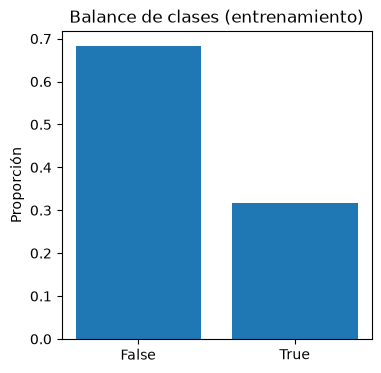

In [4]:
proporcion_clases = y_train.value_counts(normalize=True)
print(proporcion_clases)

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(proporcion_clases.index.astype(str), proporcion_clases.values)
ax.set_ylabel("Proporción")
ax.set_title("Balance de clases (entrenamiento)")
plt.show()

### 2.2. Ajuste de hiperparámetros -- Random Forest

Se usa `RandomizedSearchCV` en vez de una búsqueda exhaustiva (`GridSearchCV`)
porque el espacio de combinaciones es grande -- prueba una muestra aleatoria
de combinaciones en vez de todas, con validación cruzada de 5 particiones.

La métrica de ajuste es `roc_auc`, no `accuracy` -- dado el desbalance de
clases visto arriba. El prefijo `clasificador__` en cada parámetro viene de
cómo se llama ese paso dentro del `Pipeline` de `construir_pipeline()`.

In [8]:
param_distributions_rf = {
    "clasificador__n_estimators": [50, 100, 150, 200, 300],
    "clasificador__class_weight": [None, "balanced", "balanced_subsample"],
    "clasificador__max_depth": [None, 5, 10, 15, 20, 30],
    "clasificador__min_samples_leaf": [1, 2, 5, 10, 20],
    "clasificador__max_features": ["sqrt", "log2", None],
}

busqueda_rf = RandomizedSearchCV(
    estimator=construir_pipeline(),
    param_distributions=param_distributions_rf,
    n_iter=20,
    scoring="roc_auc",
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda_rf.fit(X_train, y_train)

print("Mejores hiperparámetros (Random Forest):", busqueda_rf.best_params_)
print(f"Mejor AUC promedio (validación cruzada): {busqueda_rf.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros (Random Forest): {'clasificador__n_estimators': 100, 'clasificador__min_samples_leaf': 20, 'clasificador__max_features': 'sqrt', 'clasificador__max_depth': 20, 'clasificador__class_weight': 'balanced_subsample'}
Mejor AUC promedio (validación cruzada): 0.831


### Resultados de la búsqueda hiperparámetros (Random Forest)

In [10]:
resultados_rf = pd.DataFrame(busqueda_rf.cv_results_)
resultados_rf = resultados_rf.sort_values("mean_test_score", ascending=False)

columnas_interes = [c for c in resultados_rf.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score"
]
resultados_rf[columnas_interes].head(5)

,param_clasificador__n_estimators,param_clasificador__min_samples_leaf,param_clasificador__max_features,param_clasificador__max_depth,param_clasificador__class_weight,mean_test_score,std_test_score
14,100,20,sqrt,20,balanced_subsample,0.830891,0.012405
3,100,20,log2,20,NaN,0.830621,0.013018
15,200,10,log2,None,NaN,0.828033,0.013197
4,50,1,log2,10,balanced_subsample,0.827517,0.014315
8,100,5,sqrt,5,balanced,0.827207,0.015106


### 2.3. Ajuste de hiperparámetros -- HistGradientBoostingClassifier

Segundo modelo a comparar: un *gradient boosting* que agrupa valores
numéricos en "bins" en vez de construir árboles sin restricciones -- suele
lograr exactitud similar o mejor que Random Forest con modelos bastante
más livianos (quedó anotado como trabajo futuro en el documento del
modelo).

Usa el **mismo preprocesamiento** que el Random Forest (mismo
`ColumnTransformer`: imputación + One-Hot para categóricas, imputación por
mediana para numéricas), para que la comparación sea justa -- la única
diferencia entre los dos pipelines es el clasificador final.
`HistGradientBoostingClassifier` sí podría recibir las categóricas de forma
nativa (sin One-Hot) y manejar nulos sin imputación previa, pero tomar esa
ruta distinta haría que los dos modelos ya no estén viendo exactamente los
mismos datos de entrada -- se deja como posible mejora futura, no como
parte de esta comparación.

In [11]:
def construir_pipeline_hgb() -> Pipeline:
    """Mismo preprocesamiento que construir_pipeline() (Random Forest, en
    modelo/entrena_y_predice.py) -- se duplica aquí porque esa función tiene
    el clasificador final fijo. Si HistGradientBoostingClassifier termina
    siendo el modelo elegido, vale la pena refactorizar y compartir un solo
    constructor de preprocesador entre ambos pipelines en el archivo de
    producción, en vez de mantener esta copia."""
    transformador_categoricas = Pipeline([
        ("imputar", SimpleImputer(strategy="constant", fill_value="desconocido")),
        ("codificar", OneHotEncoder(handle_unknown="ignore")),
    ])
    transformador_numericas = SimpleImputer(strategy="median")

    preprocesador = ColumnTransformer([
        ("categoricas", transformador_categoricas, COLUMNAS_CATEGORICAS),
        ("numericas", transformador_numericas, COLUMNAS_NUMERICAS),
    ])
    return Pipeline([
        ("preprocesamiento", preprocesador),
        ("clasificador", HistGradientBoostingClassifier(random_state=42)),
    ])

In [12]:
param_distributions_hgb = {
    "clasificador__max_iter": [50, 100, 150, 200, 300],
    "clasificador__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clasificador__max_depth": [None, 3, 5, 10, 15],
    "clasificador__max_leaf_nodes": [15, 31, 63, 127],
    "clasificador__min_samples_leaf": [10, 20, 50, 100],
    "clasificador__l2_regularization": [0, 0.1, 1.0, 10.0],
}

busqueda_hgb = RandomizedSearchCV(
    estimator=construir_pipeline_hgb(),
    param_distributions=param_distributions_hgb,
    n_iter=20,
    scoring="roc_auc",
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda_hgb.fit(X_train, y_train)

print("Mejores hiperparámetros (HistGradientBoosting):", busqueda_hgb.best_params_)
print(f"Mejor AUC promedio (validación cruzada): {busqueda_hgb.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros (HistGradientBoosting): {'clasificador__min_samples_leaf': 50, 'clasificador__max_leaf_nodes': 31, 'clasificador__max_iter': 200, 'clasificador__max_depth': 3, 'clasificador__learning_rate': 0.05, 'clasificador__l2_regularization': 10.0}
Mejor AUC promedio (validación cruzada): 0.831


### Resultados de la búsqueda (HistGradientBoostingClassifier)

In [13]:
resultados_hgb = pd.DataFrame(busqueda_hgb.cv_results_).sort_values("mean_test_score", ascending=False)
columnas_interes = [c for c in resultados_hgb.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score"
]
top10_hgb = resultados_hgb[columnas_interes].head(10)
top10_hgb

,param_clasificador__min_samples_leaf,param_clasificador__max_leaf_nodes,param_clasificador__max_iter,param_clasificador__max_depth,param_clasificador__learning_rate,param_clasificador__l2_regularization,mean_test_score,std_test_score
9,50,31,200,3,0.05,10.0,0.830739,0.014304
3,100,31,300,15,0.01,10.0,0.827711,0.015104
16,50,15,200,3,0.01,0.0,0.827700,0.012978
1,50,127,100,5,0.05,10.0,0.826778,0.014618
6,50,31,200,3,0.10,10.0,0.826663,0.013715
18,20,15,200,15,0.05,0.0,0.824126,0.015524
4,10,127,50,5,0.05,1.0,0.823992,0.015437
8,50,15,300,None,0.05,0.0,0.820556,0.015828
2,50,63,100,None,0.05,10.0,0.819516,0.017309
15,100,31,150,3,0.20,0.1,0.817584,0.014725


### 2.4. Validación: curva ROC comparada

Los dos modelos ya están reentrenados internamente sobre todo `X_train`
(lo hace `RandomizedSearchCV` al terminar la búsqueda) -- se evalúan ambos
sobre el mismo `X_test`, nunca visto durante el ajuste de ninguno de los
dos.

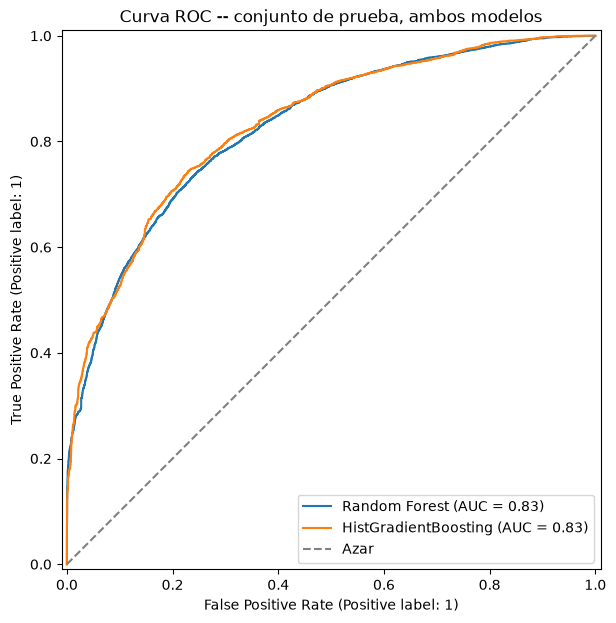

AUC Random Forest:        0.828
AUC HistGradientBoosting: 0.833


In [14]:
mejor_modelo_rf = busqueda_rf.best_estimator_
mejor_modelo_hgb = busqueda_hgb.best_estimator_

probabilidades_test_rf = mejor_modelo_rf.predict_proba(X_test)[:, 1]
probabilidades_test_hgb = mejor_modelo_hgb.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 7))
RocCurveDisplay.from_predictions(y_test, probabilidades_test_rf, ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, probabilidades_test_hgb, ax=ax, name="HistGradientBoosting")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC -- conjunto de prueba, ambos modelos")
ax.legend()
plt.show()

print(f"AUC Random Forest:        {roc_auc_score(y_test, probabilidades_test_rf):.3f}")
print(f"AUC HistGradientBoosting: {roc_auc_score(y_test, probabilidades_test_hgb):.3f}")

### 2.5 Curva Precision-Recall comparada

Mismo criterio que con la ROC: con clases desbalanceadas, Precision-Recall
suele dar una imagen más honesta que la ROC sola.

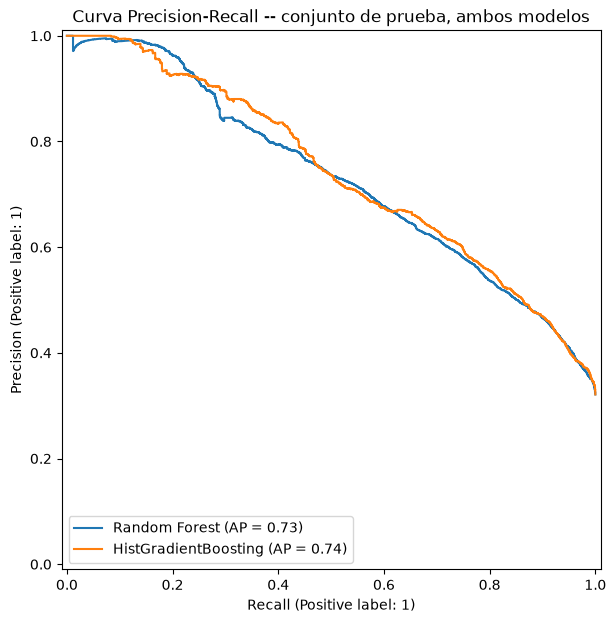

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
PrecisionRecallDisplay.from_predictions(y_test, probabilidades_test_rf, ax=ax, name="Random Forest")
PrecisionRecallDisplay.from_predictions(y_test, probabilidades_test_hgb, ax=ax, name="HistGradientBoosting")
ax.set_title("Curva Precision-Recall -- conjunto de prueba, ambos modelos")
plt.show()

### 2.6. Evaluación del desempeño con el conjunto de prueba

Métricas "duras" (umbral de decisión 0.5) para los dos modelos, lado a
lado, más la comparación contra el baseline ingenuo.

In [16]:
predicciones_test_rf = mejor_modelo_rf.predict(X_test)
predicciones_test_hgb = mejor_modelo_hgb.predict(X_test)

baseline_ingenuo = y_train.value_counts(normalize=True).max()
print(f"Baseline ingenuo (clase mayoritaria): {baseline_ingenuo:.3f}\n")

print("=== Random Forest ===")
print(f"Exactitud: {accuracy_score(y_test, predicciones_test_rf):.3f}")
print(classification_report(y_test, predicciones_test_rf, target_names=["no_adjudicado", "adjudicado"]))

print("\n=== HistGradientBoosting ===")
print(f"Exactitud: {accuracy_score(y_test, predicciones_test_hgb):.3f}")
print(classification_report(y_test, predicciones_test_hgb, target_names=["no_adjudicado", "adjudicado"]))

Baseline ingenuo (clase mayoritaria): 0.684

=== Random Forest ===
Exactitud: 0.765
               precision    recall  f1-score   support

no_adjudicado       0.85      0.80      0.82     17859
   adjudicado       0.62      0.69      0.65      8456

     accuracy                           0.76     26315
    macro avg       0.73      0.75      0.74     26315
 weighted avg       0.77      0.76      0.77     26315


=== HistGradientBoosting ===
Exactitud: 0.781
               precision    recall  f1-score   support

no_adjudicado       0.80      0.91      0.85     17859
   adjudicado       0.73      0.51      0.60      8456

     accuracy                           0.78     26315
    macro avg       0.76      0.71      0.72     26315
 weighted avg       0.77      0.78      0.77     26315



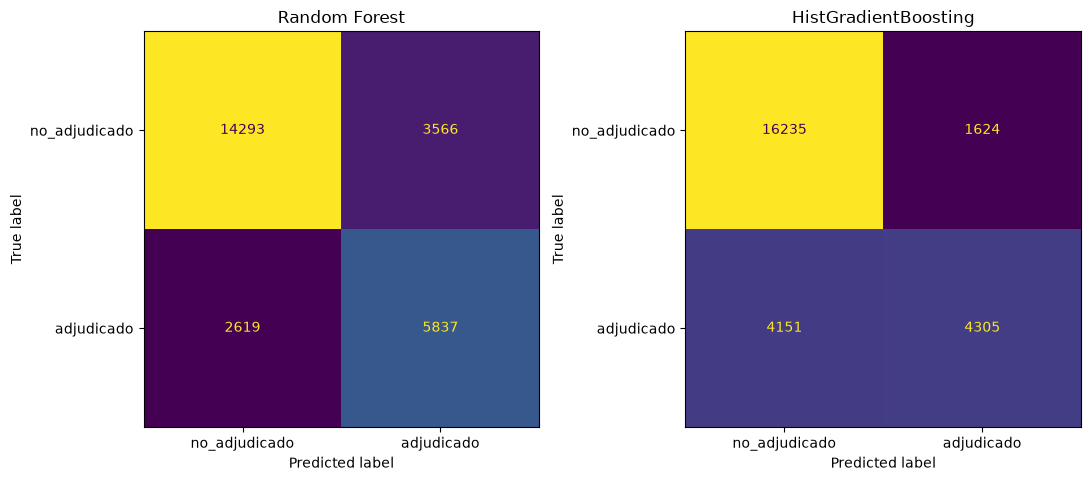

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones_test_rf, ax=axes[0],
    display_labels=["no_adjudicado", "adjudicado"], colorbar=False,
)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones_test_hgb, ax=axes[1],
    display_labels=["no_adjudicado", "adjudicado"], colorbar=False,
)
axes[1].set_title("HistGradientBoosting")

plt.tight_layout()
plt.show()

### 2.7. Importancia de variables para Random Forest

Solo para Random Forest: `HistGradientBoostingClassifier` no expone
`feature_importances_` como atributo nativo del modelo. La forma
equivalente de medir importancia ahí es *permutation importance*
(`sklearn.inspection.permutation_importance`, aplicable a cualquier
modelo) -- se deja fuera de esta comparación por alcance, pero es el
siguiente paso natural si HistGradientBoosting termina siendo el modelo
elegido.

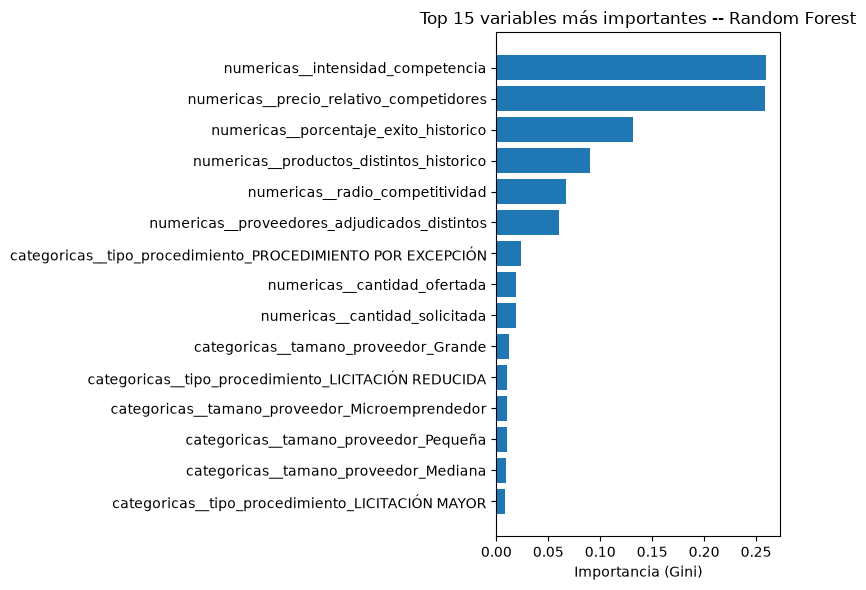

,variable,importancia
16,numericas__intensidad_competencia,0.260022
17,numericas__precio_relativo_competidores,0.258127
11,numericas__porcentaje_exito_historico,0.131029
13,numericas__productos_distintos_historico,0.090032
12,numericas__radio_competitividad,0.067048
10,numericas__proveedores_adjudicados_distintos,0.060687
8,categoricas__tipo_procedimiento_PROCEDIMIENTO ...,0.023987
15,numericas__cantidad_ofertada,0.018813
14,numericas__cantidad_solicitada,0.018484
0,categoricas__tamano_proveedor_Grande,0.011700


In [20]:
nombres_columnas = mejor_modelo_rf.named_steps["preprocesamiento"].get_feature_names_out()
importancias = mejor_modelo_rf.named_steps["clasificador"].feature_importances_

df_importancias = (
    pd.DataFrame({"variable": nombres_columnas, "importancia": importancias})
    .sort_values("importancia", ascending=False)
)

top15 = df_importancias.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["variable"], top15["importancia"])
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 15 variables más importantes -- Random Forest")
plt.tight_layout()
plt.show()

df_importancias

---

## 3. Modelo de K-Means Clustering (no supervisado)
A continuación se desarrolla un...


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Reutiliza la misma CTE point-in-time que ya usa el modelo supervisado --
# porcentaje_exito_historico debe seguir siendo "a la fecha de cada oferta",
# sin importar que ahora el uso sea no supervisado.
from modelo.entrena_y_predice import CTE_ENRIQUECIMIENTO_HISTORICO

In [ ]:
consulta = f"""
    WITH {CTE_ENRIQUECIMIENTO_HISTORICO},
    precio_por_linea AS (
        SELECT
            o.cod_producto,
            o.monto_linea_oferta / NULLIF(o.cantidad_ofertada, 0) AS precio_unitario_crc,
            eh.porcentaje_exito_historico
        FROM final.fact_lineas_ofertas o
        LEFT JOIN enriquecimiento_historico eh
            ON eh.cedula_proveedor = o.cedula_proveedor AND eh.nro_oferta = o.nro_oferta
        WHERE o.monto_linea_oferta IS NOT NULL AND o.cantidad_ofertada > 0
    ),
    mediana_por_producto AS (
        -- Mediana histórica COMPLETA (no point-in-time): a diferencia del
        -- modelo supervisado, acá no hay un conjunto de prueba que proteger
        -- de fuga de información -- es un análisis descriptivo, no una
        -- evaluación de qué tan bien generaliza un modelo. Usar todo el
        -- historial disponible es lo correcto, no un descuido.
        SELECT cod_producto, median(precio_unitario_crc) AS precio_mediano_producto
        FROM precio_por_linea
        GROUP BY cod_producto
    )
    SELECT
        pl.porcentaje_exito_historico,
        pl.precio_unitario_crc / NULLIF(mp.precio_mediano_producto, 0) AS precio_relativo
    FROM precio_por_linea pl
    JOIN mediana_por_producto mp ON mp.cod_producto = pl.cod_producto
    WHERE pl.porcentaje_exito_historico IS NOT NULL  -- excluye proveedores en su primera oferta (ratio indefinido)
      AND pl.precio_unitario_crc IS NOT NULL
"""

df = con.execute(consulta).df()
print(f"Filas antes de filtrar outliers: {len(df):,}")

# Filtro defensivo contra outliers: fuera de este rango, casi seguro es error de digitación, o ofertas irrealistas, más que comportamiento real.
df = df[(df["precio_relativo"] > 0.005) & (df["precio_relativo"] < 500)].copy()
print(f"Filas después de filtrar: {len(df):,}")

df["log_precio_relativo"] = np.log(df["precio_relativo"])
df.describe()

In [ ]:
#Escalado de variables para clustering
X = df[["porcentaje_exito_historico", "log_precio_relativo"]].copy()
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

In [ ]:
inercias, siluetas = [], []
rango_k = range(2, 11)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_escalado)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X_escalado, etiquetas))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(list(rango_k), inercias, marker="o")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia"); axes[0].set_title("Método del codo")
axes[1].plot(list(rango_k), siluetas, marker="o")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silueta"); axes[1].set_title("Puntaje de silueta")
plt.tight_layout()
plt.show()

In [ ]:
K_ELEGIDO = 4  # ajustar según las gráficas anteriores

modelo_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
df["cluster"] = modelo_final.fit_predict(X_escalado)

fig, ax = plt.subplots(figsize=(9, 6))
dispersión = ax.scatter(
    df["porcentaje_exito_historico"], df["precio_relativo"],
    c=df["cluster"], cmap="tab10", alpha=0.3, s=8
)
ax.set_yscale("log")
ax.axhline(1, color="gray", linestyle="--", linewidth=1, label="Precio = mediana del producto")
ax.set_xlabel("Porcentaje de éxito histórico")
ax.set_ylabel("Precio relativo a la mediana del producto (escala log)")
ax.set_title(f"Clusters K-means (K={K_ELEGIDO}): éxito vs. precio relativo")
ax.legend()
plt.show()

In [ ]:
resumen = df.groupby("cluster").agg(
    cantidad_lineas=("precio_relativo", "count"),
    exito_promedio=("porcentaje_exito_historico", "mean"),
    precio_relativo_mediano=("precio_relativo", "median"),
).round(3)
resumen